# 🧠 Naive Bayes Classification Worksheet
*Titanic Survival Prediction — Categorical Naive Bayes*

---

Welcome! In this worksheet you will build a **complete Naive Bayes pipeline** on the Titanic dataset using only **categorical/discrete features**. This keeps the math simple and lets you focus on understanding the core algorithm.

> 💡 **How to use this worksheet**
> - Read each markdown cell — it explains **what** and **why**
> - Fill in every `# YOUR CODE HERE` block
> - Hints are provided in each task — use them!
> - Run cells in order from top to bottom

---

## 📋 Pipeline Steps
1. Data Loading & Exploration
2. Feature Selection & Preprocessing
3. Train-Test Split
4. Naive Bayes **from Scratch** (using frequency counts & probabilities)
5. Naive Bayes using **scikit-learn** (`CategoricalNB`)
6. Model Comparison & Evaluation


## 🛳️ Dataset Overview: Titanic

The Titanic dataset contains passenger information. Our goal is to **predict survival** (`Survived = 1` or `Survived = 0`).

### 📊 Features we will use (all discrete/categorical)

| Column | Values | Type |
|--------|--------|------|
| `Pclass` | 1, 2, 3 | Ordinal |
| `Sex` | male, female | Nominal |
| `Embarked` | C, Q, S | Nominal |
| `SibSp` | 0, 1, 2, … | Discrete |
| `Parch` | 0, 1, 2, … | Discrete |

> ✅ We intentionally **skip continuous features** like `Age` and `Fare` here. Simple (categorical) Naive Bayes works purely with **frequency counts** — no Gaussian distributions needed!


## Step 1: Data Loading & Exploration

### 📌 What to do:
- Import `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn`
- Load the CSV from the URL into a DataFrame called `data`
- Display the **first 5 rows**

> 💡 **Hint:** `pd.read_csv(url)` loads remote CSV files directly into a DataFrame.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# YOUR CODE HERE
# 1. Load the dataset into 'data'
data = pd.read_csv(url)

# 2. Display the first 5 rows
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 🔎 Explore the Data

Check data types, missing values, and the distribution of the target column.

> 💡 **Hint:** Use `data.info()`, `data.isnull().sum()`, and `sns.countplot()`.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


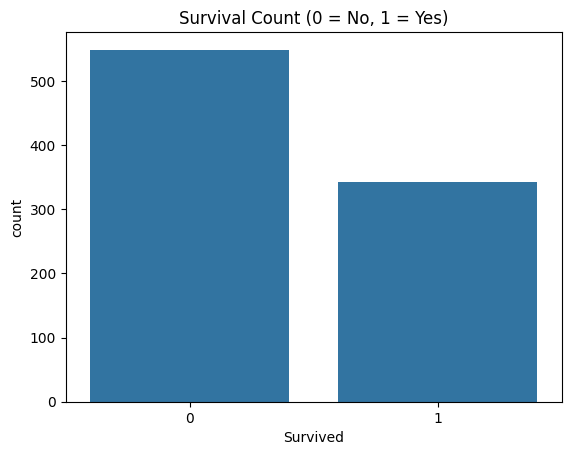

In [4]:
data.info()

data.isnull().sum()

sns.countplot(x='Survived', data=data)
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()

## Step 2: Feature Selection & Preprocessing

We will keep only the **5 categorical/discrete features** listed in the overview, plus the target column `Survived`.

### 📌 What to do:
**A) Select columns:** Keep only `Pclass`, `Sex`, `Embarked`, `SibSp`, `Parch`, and `Survived`.

**B) Handle missing values:**
- `Embarked` has 2 missing values → fill with the **most frequent** value (mode)

**C) Encode text columns:**
- `Sex`: `female` → 0, `male` → 1
- `Embarked`: `C` → 0, `Q` → 1, `S` → 2

> 💡 **Hint for (B):** `data['Embarked'].mode()[0]` gives the most frequent value. Use `.fillna()` to fill missing entries.

> 💡 **Hint for (C):** Use `LabelEncoder` from `sklearn.preprocessing`, or use a dictionary with `.map()` — either works.


In [6]:
from sklearn.preprocessing import LabelEncoder

# A) Select only the relevant columns
cols = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch', 'Survived']
df = data[cols].copy()

# B) Fill missing values in 'Embarked' with the most frequent value
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# C) Encode 'Sex' and 'Embarked' as integers
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Confirm result
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print(df.head())

Shape: (891, 6)
Missing values: 0
   Pclass  Sex  Embarked  SibSp  Parch  Survived
0       3    1         2      1      0         0
1       1    0         0      1      0         1
2       3    0         2      0      0         1
3       1    0         2      1      0         1
4       3    1         2      0      0         0


## 📚 How Simple (Categorical) Naive Bayes Works

### 🔑 Core Idea

For a new passenger with features $X = (x_1, x_2, \dots, x_n)$, we want to find the class $y$ that maximises:

$$P(y \mid X) \propto P(y) \times \prod_{i=1}^{n} P(x_i \mid y)$$

We pick whichever class gives the **higher posterior probability**.

---

### 📐 The Three Quantities

| Quantity | Formula | How to compute |
|----------|---------|----------------|
| **Prior** $P(y)$ | $\frac{\text{count of class } y}{\text{total samples}}$ | Count rows per class |
| **Likelihood** $P(x_i \mid y)$ | $\frac{\text{count}(x_i, y)}{\text{count}(y)}$ | Count feature value within class |
| **Laplace Smoothing** | Add 1 to every count | Prevents zero probabilities |

---

### 🛡️ Why Laplace Smoothing?

If a feature value never appears with a class in training data, the raw probability is **zero**, which kills the entire product. Adding 1 to every count (and adjusting the denominator) avoids this.

$$P(x_i \mid y) = \frac{\text{count}(x_i, y) + 1}{\text{count}(y) + k}$$

where $k$ is the number of unique values of feature $x_i$.

---

### 💡 Example

Suppose we have 3 passengers:

| Pclass | Sex | Survived |
|--------|-----|----------|
| 3 | male | 0 |
| 1 | female | 1 |
| 3 | female | 1 |

For a new passenger: `Pclass=3, Sex=female`:

- $P(Survived=1) = 2/3$
- $P(Pclass=3 \mid Survived=1) = 1/2$
- $P(Sex=female \mid Survived=1) = 2/2 = 1$
- **Posterior(1)** ∝ $2/3 \times 1/2 \times 1 = 0.333$

Do the same for class 0, pick the higher one. ✅


## Step 3: Train-Test Split

Split the cleaned DataFrame into features `X` and target `y`, then into train/test sets.

### 📌 What to do:
- `X` = all columns except `Survived`
- `y` = the `Survived` column
- Use `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
- Print the sizes of each split

> 💡 **Hint:** `stratify=y` ensures the same survival ratio in both splits.


In [7]:
from sklearn.model_selection import train_test_split

# 1. Define X and y
X = df.drop('Survived', axis=1)
y = df['Survived']

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Print sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Training samples: 712
Testing samples: 179
X_train shape: (712, 5)
y_train shape: (712,)
X_test shape: (179, 5)
y_test shape: (179,)


## Step 4: Naive Bayes from Scratch 🔧

You will now implement a **Categorical Naive Bayes** classifier using only Python and NumPy.

The class has three methods:

### `fit(X, y)` — Training
Compute and store:
1. **Priors**: `P(class)` for each class
2. **Likelihoods**: `P(feature_value | class)` for every feature, every unique value, every class

Use **Laplace smoothing** (add 1 to counts).

---

### `_log_likelihood(x)` — Score one sample
Given a single sample `x` (one row of feature values), return a dictionary mapping each class to its **log posterior**:

$$\text{log\_posterior}(y) = \log P(y) + \sum_i \log P(x_i \mid y)$$

---

### `predict(X)` — Predict all samples
For each row in `X`, call `_log_likelihood` and return the class with the **highest log posterior**.

---

> 💡 **Storage tip:** Store likelihoods in a nested dictionary:
> `self.likelihoods[feature_name][class][feature_value] = probability`

> 💡 **Log tip:** Use `np.log()`. Add log-priors and log-likelihoods (instead of multiplying probabilities). This avoids underflow.

> 💡 **Unseen values:** If a feature value wasn't seen in training, use the smoothed probability `1 / (class_count + k)` as a fallback.


In [ ]:
    class CategoricalNB_Scratch:
        def __init__(self):
            self.priors = {}  #p(x)
            self.likelihoods = {}   #p(x/y)
            self.classes = None
            self.class_counts = {}  #number of samples/class
            self.feature_unique_counts = {}

        def fit(self, X, y):
            self.classes = np.unique(y)
            n_total = X.shape[0]    #no. of samples

            # 3. Compute log priors
            for cls in self.classes:        #loop through each class
                mask_cls = (y == cls)      #mask the label
                count_cls = mask_cls.sum()
                self.class_counts[cls] = count_cls
                prior_prob = count_cls / n_total        #prior prob
                self.priors[cls] = np.log(prior_prob)

            # 4. Compute log likelihoods with Laplace smoothing
            for feature in X.columns:
                self.likelihoods[feature] = {}
                unique_feature_values = X[feature].unique()
                k = len(unique_feature_values)  # k is the number of unique values for feature x_i
                self.feature_unique_counts[feature] = k

                for cls in self.classes:
                    self.likelihoods[feature][cls] = {}
                    n_cls = self.class_counts[cls]

                    # Calculate _fallback_log_prob for unseen feature values
                    # This is P(x_i | y) = 1 / (count(y) + k) if x_i was not seen with y
                    self.likelihoods[feature][cls]['_fallback_log_prob'] = np.log(1 / (n_cls + k))

                    X_cls = X[y == cls]

                    for val in unique_feature_values:
                        count_val_in_cls = (X_cls[feature] == val).sum()
                        # Apply Laplace smoothing
                        prob = (count_val_in_cls + 1) / (n_cls + k)
                        self.likelihoods[feature][cls][val] = np.log(prob)

        def _log_likelihood(self, x):
            # Placeholder - will be implemented in a later step
            # Given a single sample x, return a dictionary mapping each class to its log posterior.
            # log_posterior(y) = log P(y) + sum_i log P(x_i | y)
            log_posteriors = {}
            for cls in self.classes:
                log_posterior = self.priors[cls]
                for feature_idx, feature_name in enumerate(x.index):
                    feature_value = x[feature_name]
                    # Check if the feature_value was seen with this class during training
                    if feature_value in self.likelihoods[feature_name][cls]:
                        log_posterior += self.likelihoods[feature_name][cls][feature_value]
                    else:
                        # Use fallback probability for unseen feature values
                        log_posterior += self.likelihoods[feature_name][cls]['_fallback_log_prob']
                log_posteriors[cls] = log_posterior
            return log_posteriors

        def predict(self, X):
            # Placeholder - will be implemented in a later step
            # For each row in X, call _log_likelihood and return the class with the highest log posterior.
            predictions = []
            for idx, row in X.iterrows():
                log_posteriors = self._log_likelihood(row)
                predicted_class = max(log_posteriors, key=log_posteriors.get)
                predictions.append(predicted_class)
            return np.array(predictions)

### ▶️ Train and Predict with Your Scratch Model

Once the class above is complete, run this cell.


In [20]:
# YOUR CODE HERE
# 1. Create an instance of CategoricalNB_Scratch
# 2. Fit it on X_train, y_train
# 3. Predict on X_test, store result in y_pred_scratch

scratch_model = CategoricalNB_Scratch()
scratch_model.fit(X_train, y_train)
y_pred_scratch = scratch_model.predict(X_test)
print("Scratch model training and prediction complete.")

Scratch model training and prediction complete.


## Step 5: Naive Bayes with Scikit-learn 📦

Now use scikit-learn's `CategoricalNB`, which is designed exactly for discrete/categorical features.

### 📌 What to do:
- Import `CategoricalNB` from `sklearn.naive_bayes`
- Create the model and fit it on `X_train`, `y_train`
- Predict on `X_test` and store the result in `y_pred_lib`

> 💡 **Hint:** `CategoricalNB` expects non-negative integer inputs — your encoded features already satisfy this.

> 💡 **Laplace smoothing** is controlled by the `alpha` parameter (default = 1.0), which matches what you implemented from scratch.


In [21]:
from sklearn.naive_bayes import CategoricalNB

# 1. Create a CategoricalNB model (use default alpha=1.0)
nb_lib = CategoricalNB(alpha=1.0)

# 2. Fit on training data
nb_lib.fit(X_train, y_train)

# 3. Predict on test data, store in y_pred_lib
y_pred_lib = nb_lib.predict(X_test)

print("Scikit-learn CategoricalNB model training and prediction complete.")

Scikit-learn CategoricalNB model training and prediction complete.


## Step 6: Model Comparison & Evaluation 📊

Evaluate both models using standard classification metrics.

### 📌 Metrics to compute:

| Metric | Meaning |
|--------|---------|
| **Accuracy** | % of total predictions that are correct |
| **Precision** | Of predicted survivors, how many actually survived |
| **Recall** | Of actual survivors, how many did we correctly identify |
| **F1-score** | Balanced measure of precision and recall |
| **Confusion Matrix** | TP / FP / TN / FN breakdown |

### 📌 What to do:
- Complete the `evaluate_model` function
- Call it once for the scratch model and once for the sklearn model
- Compare the results

> 💡 **Hint:** Use `accuracy_score`, `classification_report`, `confusion_matrix` from `sklearn.metrics`.  
> For the heatmap: `sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])`


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(name, y_true, y_pred):
    """
    Print accuracy + classification report and show a confusion matrix heatmap.
    """
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # 1. Print accuracy_score
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # 2. Print classification_report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # 3. Compute confusion matrix and plot as heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()



  Categorical NB — From Scratch
Accuracy: 0.7821

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       110
           1       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



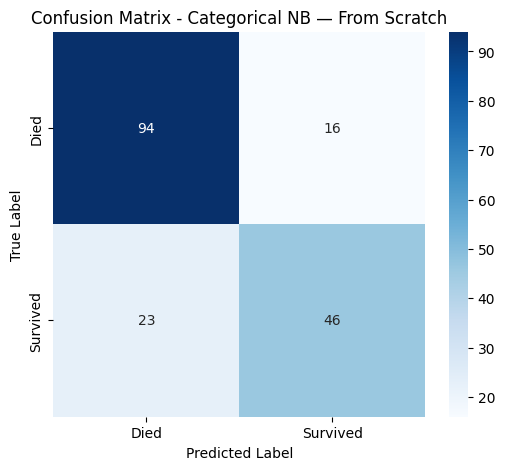

In [23]:
# Evaluate scratch implementation
evaluate_model("Categorical NB — From Scratch", y_test, y_pred_scratch)



  Categorical NB — Scikit-learn
Accuracy: 0.7821

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       110
           1       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



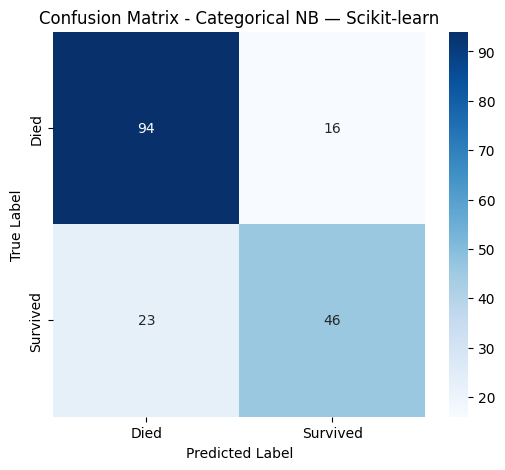

In [24]:
# Evaluate scikit-learn implementation
evaluate_model("Categorical NB — Scikit-learn", y_test, y_pred_lib)


## 🔍 Manual Probability Check (Optional but Highly Recommended!)

Pick **one specific passenger** from the test set and manually trace through the Naive Bayes calculation yourself to verify your model's prediction.

### 📌 What to do:
- Choose a row from `X_test` (e.g., the first row)
- Print its feature values
- Manually compute `P(Survived=1 | features)` and `P(Survived=0 | features)` step by step
- Check that your scratch model predicts the same class

> 💡 **Hint:** Use `X_test.iloc[0]` to get the first test row and `scratch_model._log_posterior(row)` to see the scores.


In [26]:
# 1. Pick the first row of X_test
sample_idx = 0
sample = X_test.iloc[sample_idx]
actual_label = y_test.iloc[sample_idx]

# 2. Print its feature values
print(f"Selected sample (index {X_test.index[sample_idx]}):")
print(sample)

# 3. Call _log_likelihood on it and print the class scores
log_posteriors = scratch_model._log_likelihood(sample)
print(f"\nLog Posterior Scores for sample:\n{log_posteriors}")

# Find the predicted class from the log posteriors
predicted_class_manual = max(log_posteriors, key=log_posteriors.get)

# 4. Print what the model predicted vs the actual label
print(f"\nPredicted class by scratch model: {predicted_class_manual}")
print(f"Actual label: {actual_label}")
print(f"Prediction matches actual: {predicted_class_manual == actual_label}")

Selected sample (index 565):
Pclass      3
Sex         1
Embarked    2
SibSp       2
Parch       0
Name: 565, dtype: int64

Log Posterior Scores for sample:
{np.int64(0): np.float64(-5.2045921382325195), np.int64(1): np.float64(-7.208914863630388)}

Predicted class by scratch model: 0
Actual label: 0
Prediction matches actual: True


## 🤔 Reflection Questions

Think about and answer the following questions (as comments or in a markdown cell):

1. Your scratch model and the sklearn model should give very similar (or identical) accuracy. If they differ slightly, what might cause the difference?
2. What does the confusion matrix tell you about which class the model predicts better?
3. Why do we use **log probabilities** instead of multiplying raw probabilities directly?
4. What is **Laplace smoothing** and what problem does it solve? What happens if you set `alpha=0` in `CategoricalNB`?
5. We dropped `Age` and `Fare` in this worksheet. How would you include them in a Naive Bayes model? Which variant would you use?
6. *(Bonus)* The Naive Bayes assumption is that all features are **independent**. Do you think `Pclass` and `Fare` are truly independent? What effect might this have on the model?


In [ ]:
# Write your answers as comments here:

# Q1:

# Q2:

# Q3:

# Q4:

# Q5:

# Q6 (Bonus):
